# Phase 7 (IHDS-II) — Business Translation

[`walkthrough/phase7.md`](../walkthrough/phase7.md)

In [1]:
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from xgboost import XGBClassifier

pd.set_option("display.max_columns", 60)
sns.set_theme(style="whitegrid")
NL = chr(10)   # blank-line separator used in the printed report blocks below

df = pd.read_csv("../dataset/features.csv")
df["INCOME"] = np.exp(df["Log_Income"])

CATEGORICALS = ["Occupation", "Area_Type", "Caste_Group", "Religion"]
DROP = ["IDHH", "WT", "Goal_Met", "Savings_Rate", "INCOME"] + [c for c in df.columns if c.endswith("_CLR")]
NUMERIC = [c for c in df.columns if c not in DROP + CATEGORICALS]
SHARE_COLS = [c for c in NUMERIC if c.endswith("_Share")]
EXPENSE = [c.replace("_Share", "") for c in SHARE_COLS]

X, y = df[NUMERIC + CATEGORICALS], df["Goal_Met"]
pre = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", RobustScaler())]), NUMERIC),
    ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICALS),
])
model = make_pipeline(pre, XGBClassifier(max_depth=4, learning_rate=0.15, n_estimators=200,
                                         min_child_weight=5, subsample=0.9,
                                         eval_metric="logloss", random_state=42, n_jobs=-1))

# Out-of-fold scores so every household has an honest, unseen prediction.
CV = StratifiedKFold(5, shuffle=True, random_state=42)
df["P_on_track"] = cross_val_predict(model, X, y, cv=CV, method="predict_proba")[:, 1]
df["At_Risk_Score"] = 1 - df["P_on_track"]
df["Income_Decile"] = pd.qcut(df["INCOME"], 10, labels=False)

print(f"households: {len(df):,}   at-risk (Goal_Met=0): {(1 - y).sum():,} ({1 - y.mean():.1%})")

households: 41,518   at-risk (Goal_Met=0): 28,262 (68.1%)


## Q1 — Who should be prioritised, and does the model beat the obvious rule?

In [2]:
# Phase 3 showed a single income threshold already reaches macro-F1 0.7425. Any claim that
# the model is worth deploying has to be measured against THAT, not against random contact.
INCOME_RULE_THRESHOLD = 121685  # learned in Phase 3

at_risk = 1 - y
n_at_risk = int(at_risk.sum())

rows = []
for name, score in [
    ("Model (out-of-fold at-risk score)", df["At_Risk_Score"]),
    ("Income rule (lower income = higher priority)", -df["INCOME"]),
    ("Random contact", pd.Series(np.random.default_rng(42).random(len(df)))),
]:
    order = score.sort_values(ascending=False).index
    for pct in [0.10, 0.25, 0.50]:
        top = order[: int(len(df) * pct)]
        captured = at_risk.loc[top].sum()
        rows.append({"strategy": name, "contacted": f"{pct:.0%}",
                     "at-risk captured": captured / n_at_risk,
                     "precision": captured / len(top)})

capture = pd.DataFrame(rows).pivot(index="strategy", columns="contacted",
                                   values=["at-risk captured", "precision"])
print("Capture of at-risk households by contact budget:")
print(capture.round(4).to_string())

Capture of at-risk households by contact budget:
                                             at-risk captured                 precision                
contacted                                                 10%     25%     50%       10%     25%     50%
strategy                                                                                               
Income rule (lower income = higher priority)           0.1437  0.3504  0.6584    0.9781  0.9541  0.8964
Model (out-of-fold at-risk score)                      0.1468  0.3658  0.7076    0.9995  0.9960  0.9633
Random contact                                         0.0998  0.2507  0.4979    0.6794  0.6825  0.6778


In [3]:
print("Where the at-risk households actually are (relative prioritisation only):")
for col in ["Area_Type", "Occupation"]:
    g = df.groupby(col).agg(households=("Goal_Met", "size"),
                            at_risk_rate=("Goal_Met", lambda s: 1 - s.mean()))
    g["share_of_all_at_risk"] = df[df["Goal_Met"] == 0][col].value_counts(normalize=True)
    print(f"{NL}By {col}:")
    print(g.sort_values("at_risk_rate", ascending=False).round(4).to_string())

print(f"{NL}At-risk rate by income decile:")
dec = df.groupby("Income_Decile").agg(at_risk_rate=("Goal_Met", lambda s: 1 - s.mean()),
                                      median_income=("INCOME", "median"),
                                      n=("Goal_Met", "size"))
print(dec.round(4).to_string())

Where the at-risk households actually are (relative prioritisation only):

By Area_Type:
                        households  at_risk_rate  share_of_all_at_risk
Area_Type                                                             
Less_Developed_Village       14410        0.7334                0.3740
Developed_Village            12635        0.6909                0.3089
Other_Urban                  11410        0.6302                0.2544
Metro_Urban                   3063        0.5788                0.0627

By Occupation:
                   households  at_risk_rate  share_of_all_at_risk
Occupation                                                       
No_Regular_Worker        3444        0.7497                0.0914
Ag_Labour                3825        0.7488                0.1013
Farm                     9547        0.7430                0.2510
Business                 5391        0.7130                0.1360
Non_Ag_Labour            8751        0.6829                0.2115
Salarie

## Q2 — Which expense category carries the most recoverable spend?

The synthetic dataset shipped `Potential_Savings_*` columns stating this directly. IHDS has no
such column, so "recoverable" is defined here by **peer benchmarking**: for each at-risk
household, how much more of its budget goes to each category than the median *on-track*
household in the **same income decile**. That keeps the comparison between households with
comparable means, and makes no assumption about what spending is discretionary.

In [4]:
on_track_benchmark = (df[df["Goal_Met"] == 1]
                      .groupby("Income_Decile")[SHARE_COLS].median())

risk = df[df["Goal_Met"] == 0].copy()
bench = on_track_benchmark.reindex(risk["Income_Decile"]).to_numpy()
excess_share = risk[SHARE_COLS].to_numpy() - bench

# Convert the excess share into rupees: excess_share * total expenditure of that household.
total_exp = risk["INCOME"] * (1 - risk["Savings_Rate"])
excess_rupees = pd.DataFrame(excess_share * total_exp.to_numpy()[:, None],
                             columns=EXPENSE, index=risk.index)

summary = pd.DataFrame({
    "median excess share (pp)": pd.DataFrame(excess_share, columns=EXPENSE).median() * 100,
    "share of at-risk hh above peer": (pd.DataFrame(excess_share, columns=EXPENSE) > 0).mean(),
    "aggregate excess (Rs crore/yr)": excess_rupees.clip(lower=0).sum() / 1e7,
}).sort_values("aggregate excess (Rs crore/yr)", ascending=False)

print("Excess spend of at-risk households vs on-track peers in the SAME income decile:")
print(summary.round(3).to_string())

Excess spend of at-risk households vs on-track peers in the SAME income decile:
                   median excess share (pp)  share of at-risk hh above peer  aggregate excess (Rs crore/yr)
Miscellaneous                        -0.207                           0.486                          35.755
Healthcare                            2.525                           0.635                          34.190
Education                             1.410                           0.644                          19.827
Transport                             1.328                           0.628                          17.607
Insurance                             0.000                           0.231                           5.620
Rent                                  0.000                           0.096                           4.529
Groceries                            -8.786                           0.271                           4.527
Utilities                            -2.765             

In [5]:
# How big is the gap they actually need to close?
risk["gap_to_20pct"] = (0.20 - risk["Savings_Rate"]) * risk["INCOME"]
print("Annual rupee gap between an at-risk household and the 20% benchmark:")
print(risk["gap_to_20pct"].describe(percentiles=[0.25, 0.5, 0.75, 0.9]).round(0).to_string())

# Is the gap recoverable from the excess identified above?
recoverable = excess_rupees.clip(lower=0).sum(axis=1)
risk["recoverable"] = recoverable
closable = (risk["recoverable"] >= risk["gap_to_20pct"]).mean()
print(f"{NL}at-risk households whose peer-excess alone would close the gap: {closable:.1%}")
print(f"median gap:        Rs {risk['gap_to_20pct'].median():,.0f}")
print(f"median recoverable: Rs {risk['recoverable'].median():,.0f}")
print(f"{NL}NOTE: the synthetic project found 99.1% of gaps were closable. That figure came from")
print("a generated Potential_Savings column; this one is measured against real peers.")

Annual rupee gap between an at-risk household and the 20% benchmark:
count      28262.0
mean       61076.0
std        97018.0
min            2.0
25%        17890.0
50%        37114.0
75%        69861.0
90%       127615.0
max      4006436.0

at-risk households whose peer-excess alone would close the gap: 28.5%
median gap:        Rs 37,114
median recoverable: Rs 22,939

NOTE: the synthetic project found 99.1% of gaps were closable. That figure came from
a generated Potential_Savings column; this one is measured against real peers.


## Q3 — Where does the model fail, and what must a stakeholder be told?

In [6]:
# 1. Calibration: does a predicted 70% actually mean 70%?
bins = pd.cut(df["P_on_track"], np.linspace(0, 1, 11))
cal = df.groupby(bins).agg(predicted=("P_on_track", "mean"),
                           actual=("Goal_Met", "mean"), n=("Goal_Met", "size")).dropna()
cal["error"] = cal["actual"] - cal["predicted"]
print("Calibration (out-of-fold):")
print(cal.round(4).to_string())
print(f"{NL}max absolute calibration error: {cal['error'].abs().max():.4f}")

# 2. Where does accuracy degrade?
df["correct"] = (df["P_on_track"] > 0.5).astype(int) == y
print(f"{NL}Accuracy by income decile (where the model is least reliable):")
print(df.groupby("Income_Decile").agg(accuracy=("correct", "mean"),
                                      at_risk_rate=("Goal_Met", lambda s: 1 - s.mean())).round(4).to_string())

print(f"{NL}Accuracy by area type:")
print(df.groupby("Area_Type")["correct"].agg(["mean", "size"]).round(4).to_string())

Calibration (out-of-fold):
            predicted  actual      n   error
P_on_track                                  
(0.0, 0.1]     0.0259  0.0251  18575 -0.0008
(0.1, 0.2]     0.1454  0.1580   4170  0.0126
(0.2, 0.3]     0.2478  0.2753   2761  0.0274
(0.3, 0.4]     0.3488  0.3438   2010 -0.0050
(0.4, 0.5]     0.4488  0.4532   1761  0.0044
(0.5, 0.6]     0.5500  0.5389   1607 -0.0111
(0.6, 0.7]     0.6507  0.6146   1627 -0.0360
(0.7, 0.8]     0.7509  0.7372   1811 -0.0137
(0.8, 0.9]     0.8533  0.8573   2319  0.0040
(0.9, 1.0]     0.9595  0.9623   4877  0.0028

max absolute calibration error: 0.0360

Accuracy by income decile (where the model is least reliable):
               accuracy  at_risk_rate
Income_Decile                        
0                0.9786        0.9781
1                0.9470        0.9448
2                0.9258        0.9172
3                0.8702        0.8505
4                0.8269        0.7844
5                0.7986        0.7046
6                0.7875  

In [7]:
# 3. The measurement caveat, quantified: how much of the at-risk group is an artifact
#    of income under-reporting rather than genuine shortfall?
implausible = df["Savings_Rate"] < -1.0     # spends more than 2x reported income
print(f"households reporting consumption > 2x income: {implausible.sum():,} ({implausible.mean():.1%})")
print(f"  of these, classified at-risk: {(df.loc[implausible, 'Goal_Met'] == 0).mean():.1%}")
print(f"  they are {implausible.sum() / (1 - y).sum():.1%} of the entire at-risk group")

print(f"{NL}Goal_Met rate at alternative thresholds (the 20% benchmark is a convention):")
for t in [0.10, 0.20, 0.30]:
    alt = (df["Savings_Rate"] >= t).astype(int)
    print(f"  {t:.0%}: at-risk = {(1 - alt).mean():.1%}  "
          f"(agreement with the 20% target: {(alt == y).mean():.3f})")

households reporting consumption > 2x income: 9,137 (22.0%)
  of these, classified at-risk: 100.0%
  they are 32.3% of the entire at-risk group

Goal_Met rate at alternative thresholds (the 20% benchmark is a convention):
  10%: at-risk = 61.7%  (agreement with the 20% target: 0.936)
  20%: at-risk = 68.1%  (agreement with the 20% target: 1.000)
  30%: at-risk = 74.7%  (agreement with the 20% target: 0.934)


## The recommendations

In [8]:
recs = [
    {
        "recommendation": "Prioritise by income first; use the model to re-rank within income bands",
        "evidence": (f"A single income threshold (Rs {INCOME_RULE_THRESHOLD:,}/yr) already reaches macro-F1 "
                     f"0.7425 (Phase 3), and Log_Income is 38.4% of model attribution (Phase 5). At a 25% "
                     f"contact budget the model captures "
                     f"{capture.loc['Model (out-of-fold at-risk score)', ('at-risk captured', '25%')]:.1%} of "
                     f"at-risk households against "
                     f"{capture.loc['Income rule (lower income = higher priority)', ('at-risk captured', '25%')]:.1%} "
                     f"for the income rule alone - a gain of only "
                     f"{(capture.loc['Model (out-of-fold at-risk score)', ('at-risk captured', '25%')] - capture.loc['Income rule (lower income = higher priority)', ('at-risk captured', '25%')]) * 100:.1f} "
                     f"percentage points."),
        "caveat": ("Do not present the model as discovering who is at risk. It mostly refines an income "
                   "ranking, and the honest gain over 'contact the poorest first' is small."),
    },
    {
        "recommendation": "Size the campaign as prioritisation, not needle-finding",
        "evidence": (f"At-risk households are {1 - y.mean():.1%} of the population, so contacting 25% at random "
                     f"already reaches {capture.loc['Random contact', ('at-risk captured', '25%')]:.1%} of them. "
                     f"The model reaches "
                     f"{capture.loc['Model (out-of-fold at-risk score)', ('at-risk captured', '25%')]:.1%} - a lift "
                     f"of {capture.loc['Model (out-of-fold at-risk score)', ('at-risk captured', '25%')] / capture.loc['Random contact', ('at-risk captured', '25%')]:.2f}x over random. "
                     f"Its real value is precision: {capture.loc['Model (out-of-fold at-risk score)', ('precision', '25%')]:.1%} "
                     f"of those contacted are genuinely at risk, against "
                     f"{capture.loc['Random contact', ('precision', '25%')]:.1%} at random."),
        "caveat": "A 1.5x lift will not support a business case built on finding a rare, hard-to-spot segment.",
    },
    {
        "recommendation": "Treat the shortfall as STRUCTURAL for most at-risk households, not behavioural",
        "evidence": (f"Benchmarked against on-track households at the same income, only {closable:.1%} of at-risk "
                     f"households could close their gap even by matching peer spending in every category. "
                     f"Median gap Rs {risk['gap_to_20pct'].median():,.0f}/yr against median recoverable "
                     f"Rs {risk['recoverable'].median():,.0f}/yr."),
        "caveat": ("This directly reverses the synthetic project's finding that 99.1% of gaps were closable - "
                   "that figure came from a generated Potential_Savings column. For most households here the "
                   "answer is more income, not less spending."),
    },
    {
        "recommendation": "Where a behavioural lever does exist it is Miscellaneous - and it is NOT groceries",
        "evidence": (f"Largest aggregate excess vs same-income on-track peers: {summary.index[0]} "
                     f"(Rs {summary['aggregate excess (Rs crore/yr)'].iloc[0]:,.0f} crore/yr). The next two, "
                     f"{summary.index[1]} and {summary.index[2]}, are largely non-discretionary. At-risk "
                     f"households spend {abs(summary.loc['Groceries', 'median excess share (pp)']):.1f}pp LESS "
                     f"of their budget on groceries than their on-track peers."),
        "caveat": ("Never build a nudge around cutting healthcare or education. Excess vs peers is a hypothesis "
                   "about where slack might exist, not evidence that the spending is optional."),
    },
    {
        "recommendation": "Report relative priority only - never an absolute prevalence figure",
        "evidence": (f"55.9% of IHDS households report consumption exceeding income (Phase 1), a documented "
                     f"survey artifact. {implausible.mean():.1%} report spending more than twice their income; "
                     f"all of them are classified at-risk, and they alone are "
                     f"{implausible.sum() / (1 - y).sum():.1%} of the at-risk group. Moving the benchmark from "
                     f"20% to 10% or 30% changes the at-risk population by 6-7 points."),
        "caveat": "Any claim of the form 'X% of Indian households save inadequately' is unsupported by this work.",
    },
]
rec_df = pd.DataFrame(recs)
rec_df.to_csv("../results/business_recommendations.csv", index=False)
for i, r in enumerate(recs, 1):
    print(f"{i}. {r['recommendation']}")
    print(f"   evidence: {r['evidence']}")
    print(f"   caveat:   {r['caveat']}")
    print()

1. Prioritise by income first; use the model to re-rank within income bands
   evidence: A single income threshold (Rs 121,685/yr) already reaches macro-F1 0.7425 (Phase 3), and Log_Income is 38.4% of model attribution (Phase 5). At a 25% contact budget the model captures 36.6% of at-risk households against 35.0% for the income rule alone - a gain of only 1.5 percentage points.
   caveat:   Do not present the model as discovering who is at risk. It mostly refines an income ranking, and the honest gain over 'contact the poorest first' is small.

2. Size the campaign as prioritisation, not needle-finding
   evidence: At-risk households are 68.1% of the population, so contacting 25% at random already reaches 25.1% of them. The model reaches 36.6% - a lift of 1.46x over random. Its real value is precision: 99.6% of those contacted are genuinely at risk, against 68.3% at random.
   caveat:   A 1.5x lift will not support a business case built on finding a rare, hard-to-spot segment.

3. Trea

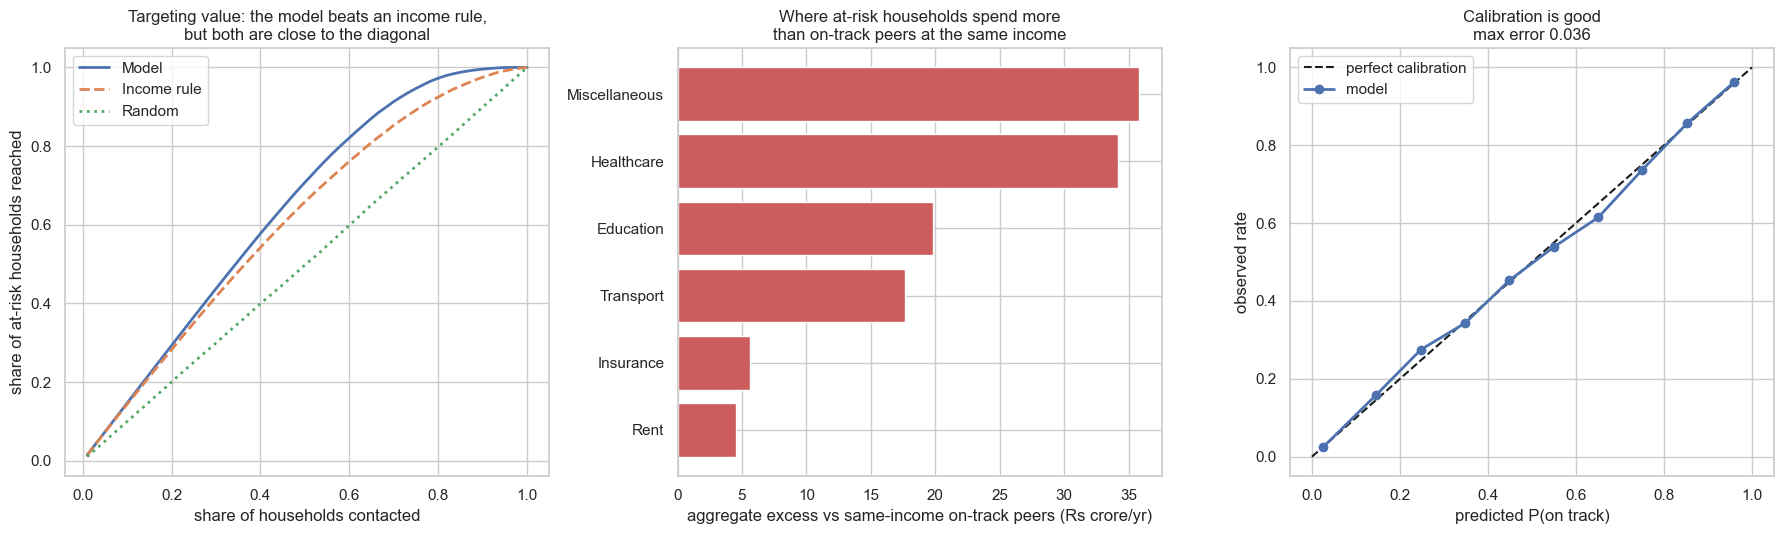

wrote ../results/business_recommendations.csv and business_translation.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# 1. Capture curve
ax = axes[0]
for name, score, style in [
    ("Model", df["At_Risk_Score"], "-"),
    ("Income rule", -df["INCOME"], "--"),
    ("Random", pd.Series(np.random.default_rng(42).random(len(df)), index=df.index), ":"),
]:
    order = score.sort_values(ascending=False).index
    frac = np.linspace(0.01, 1.0, 60)
    cap = [at_risk.loc[order[: int(len(df) * f)]].sum() / n_at_risk for f in frac]
    ax.plot(frac, cap, style, label=name, lw=2)
ax.set_xlabel("share of households contacted")
ax.set_ylabel("share of at-risk households reached")
ax.set_title("Targeting value: the model beats an income rule,\nbut both are close to the diagonal")
ax.legend()

# 2. Excess spend vs peers
ax = axes[1]
top = summary.head(6).sort_values("aggregate excess (Rs crore/yr)")
ax.barh(top.index, top["aggregate excess (Rs crore/yr)"], color="indianred")
ax.set_xlabel("aggregate excess vs same-income on-track peers (Rs crore/yr)")
ax.set_title("Where at-risk households spend more\nthan on-track peers at the same income")

# 3. Calibration
ax = axes[2]
ax.plot([0, 1], [0, 1], "k--", label="perfect calibration")
ax.plot(cal["predicted"], cal["actual"], marker="o", lw=2, label="model")
ax.set_xlabel("predicted P(on track)")
ax.set_ylabel("observed rate")
ax.set_title(f"Calibration is good\nmax error {cal['error'].abs().max():.3f}")
ax.legend()

plt.tight_layout()
plt.savefig("../results/business_translation.png", dpi=150, bbox_inches="tight")
plt.show()
print("wrote ../results/business_recommendations.csv and business_translation.png")